Intro to Data Science: Coral Bleaching Prediction Model

## Step 1: Cleaning the Dataset

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('coral.csv')

# Cleaning, removing unneccessary columns

columns_to_keep = [
    'Percent_Bleaching', 
    'ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
    'SSTA', 'SSTA_Mean', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_DHW',
    'TSA', 'TSA_Mean', 'TSA_Maximum', 'TSA_Frequency', 'TSA_DHW',
    'Turbidity', 'Windspeed', 'Depth_m', 'Distance_to_Shore', 'Exposure',
    'Date_Year', 'Date_Month', 'Country_Name', 'Ocean_Name',
    'Latitude_Degrees', 'Longitude_Degrees'
]

df = df[columns_to_keep]

# List of columns that should be numeric but are being read as text
columns_to_fix = [
    'ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
    'SSTA', 'SSTA_Mean', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_DHW',
    'TSA', 'TSA_Mean', 'TSA_Maximum', 'TSA_Frequency', 'TSA_DHW',
    'Windspeed', 'Depth_m'
]


# Missing values in Percent Bleaching, Turbidity, and Distance_to_Shore, locate missing rows and remove them

# Replace 'nd' with actual NaN, then convert column to numeric since null percent_bleaching is inconsistent
df['Percent_Bleaching'] = df['Percent_Bleaching'].replace('nd', np.nan)
df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'])

# Do the same thing w Turbidity
df['Turbidity'] = df['Turbidity'].replace('nd', np.nan)
df['Turbidity'] = pd.to_numeric(df['Turbidity'])

# Do the same thing w Distance_To_Shore
df['Distance_to_Shore'] = df['Distance_to_Shore'].replace('nd', np.nan)
df['Distance_to_Shore'] = pd.to_numeric(df['Distance_to_Shore'])

# Drop rows where the target variable is missing
df = df.dropna(subset=['Percent_Bleaching'])
df = df.dropna(subset=['Turbidity'])
df = df.dropna(subset=['Distance_to_Shore'])

# Check missing values across all remaining columns

for col in columns_to_fix:
    df[col] = df[col].replace('nd', np.nan)
    df[col] = pd.to_numeric(df[col])

df = df.dropna(subset=columns_to_fix)

print(df.isnull().sum().to_string())
print(df.shape)



# Update CSV
df.to_csv('coral_clean.csv', index=False)


C:\Users\codyl\AppData\Local\Temp\ipykernel_15296\2990731407.py:4: DtypeWarning: Columns (0: Distance_to_Shore, 1: Turbidity, 2: Percent_Bleaching) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('coral.csv')


Percent_Bleaching      0
ClimSST                0
Temperature_Mean       0
Temperature_Minimum    0
Temperature_Maximum    0
SSTA                   0
SSTA_Mean              0
SSTA_Maximum           0
SSTA_Frequency         0
SSTA_DHW               0
TSA                    0
TSA_Mean               0
TSA_Maximum            0
TSA_Frequency          0
TSA_DHW                0
Turbidity              0
Windspeed              0
Depth_m                0
Distance_to_Shore      0
Exposure               0
Date_Year              0
Date_Month             0
Country_Name           0
Ocean_Name             0
Latitude_Degrees       0
Longitude_Degrees      0
(32714, 26)


## Step 2: Explanatory Data Analysis

Histogram

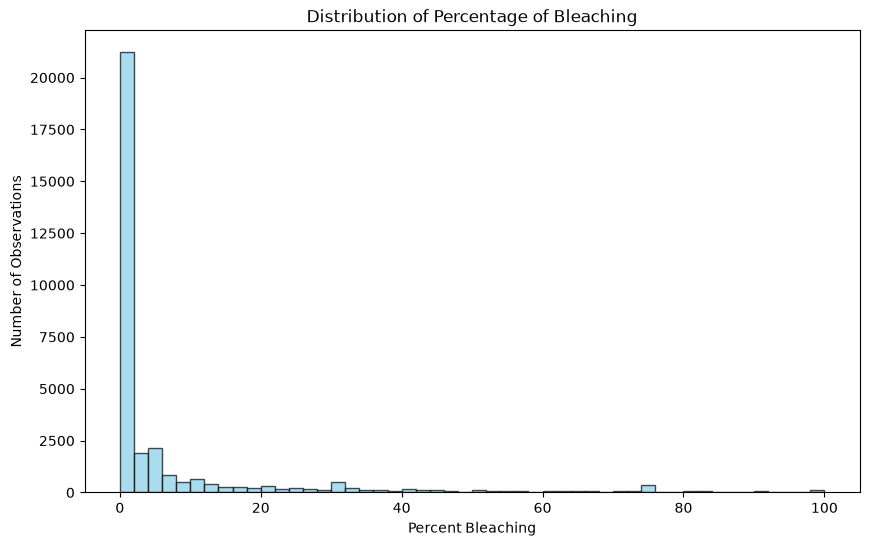

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine number of Percentage of Bleaching observations using a histogram
plt.figure(figsize=(10,6))

plt.hist(df['Percent_Bleaching'], bins=50, color="skyblue", edgecolor="black", alpha=0.7)
plt.title('Distribution of Percentage of Bleaching')
plt.xlabel('Percent Bleaching')
plt.ylabel('Number of Observations')
plt.show()

# Looks like most observations have 0% bleaching. Small spike around 75%.


Correlation Matrix

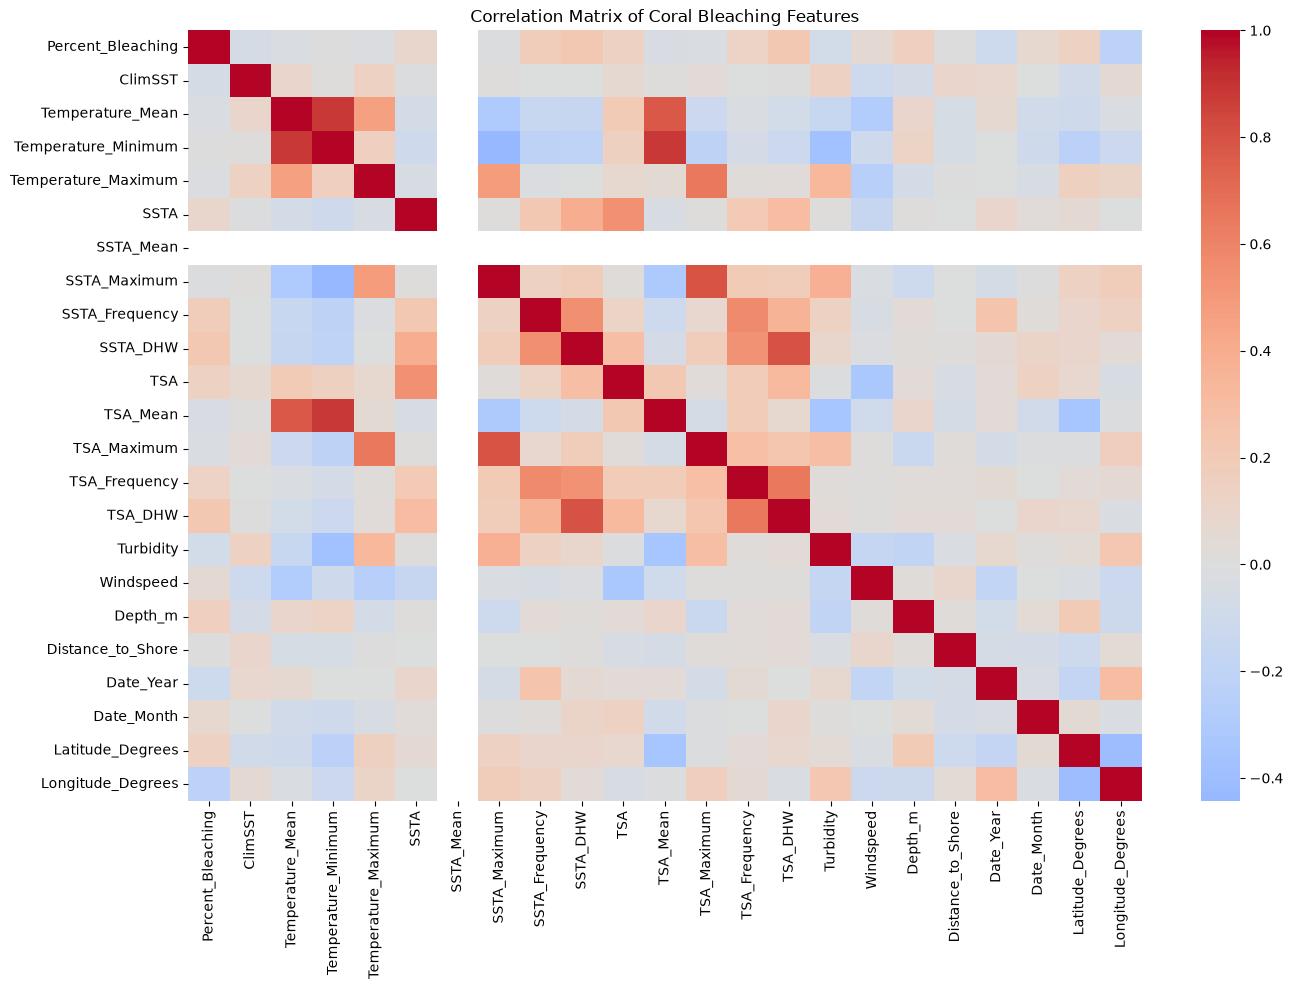

In [18]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), 
            annot=False, 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Matrix of Coral Bleaching Features')
plt.tight_layout()
plt.show()

How Average Bleaching Percentage Changes over time

Note: Number of observations increased heavily after the year 2000. Graph may be misleading

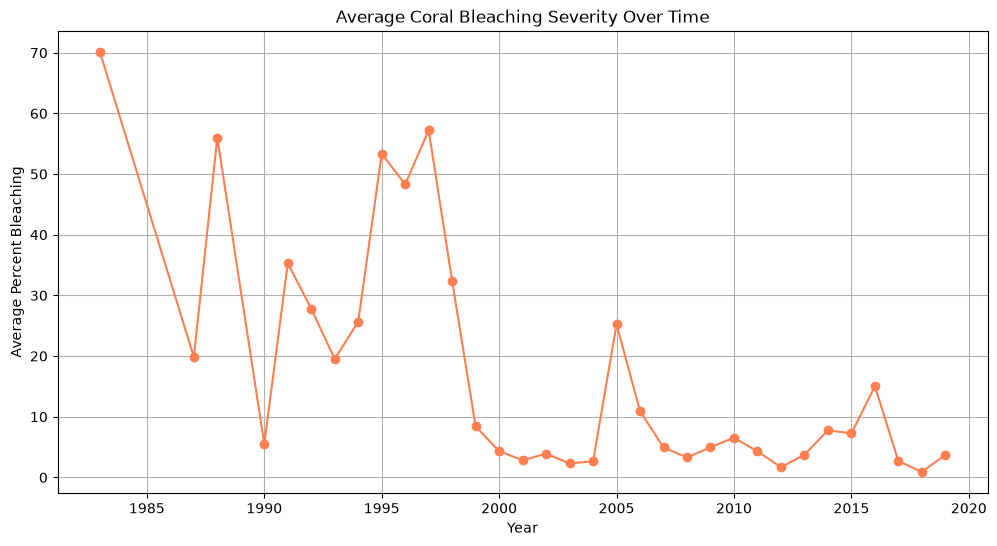

In [ ]:
yearly_bleaching = df.groupby('Date_Year')['Percent_Bleaching'].mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_bleaching.index, yearly_bleaching.values, color='coral', marker='o')
plt.title('Average Coral Bleaching Severity Over Time')
plt.xlabel('Year')
plt.ylabel('Average Percent Bleaching')
plt.grid(True)
plt.show()

Bleaching by Ocean Region

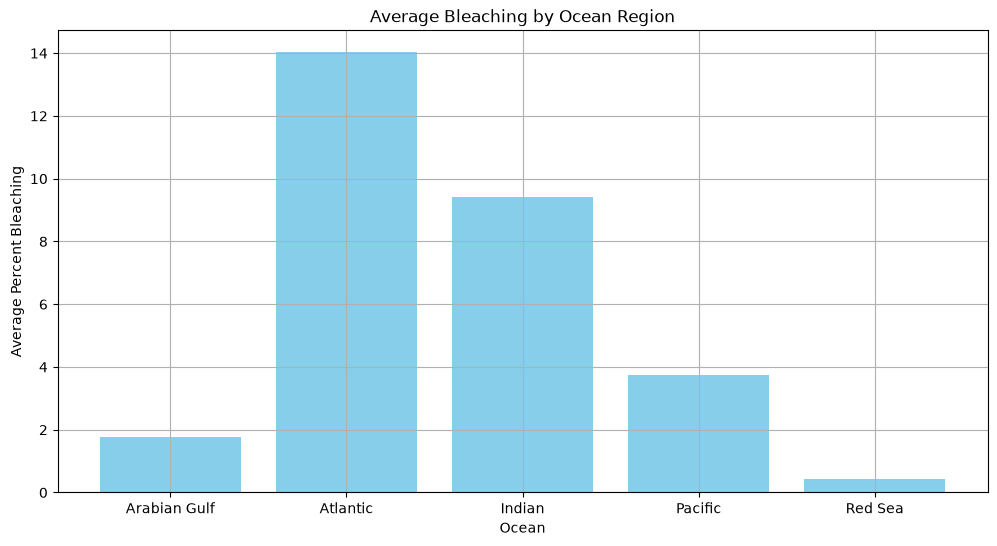

In [27]:
bleaching_by_ocean = df.groupby('Ocean_Name')['Percent_Bleaching'].mean()

plt.figure(figsize=(12,6))
plt.bar(bleaching_by_ocean.index, bleaching_by_ocean.values, color='skyblue')
plt.xlabel('Ocean')
plt.ylabel('Average Percent Bleaching')
plt.title('Average Bleaching by Ocean Region')
plt.grid(True)
plt.show()

Sea Surface Temperature vs Bleaching Percentage

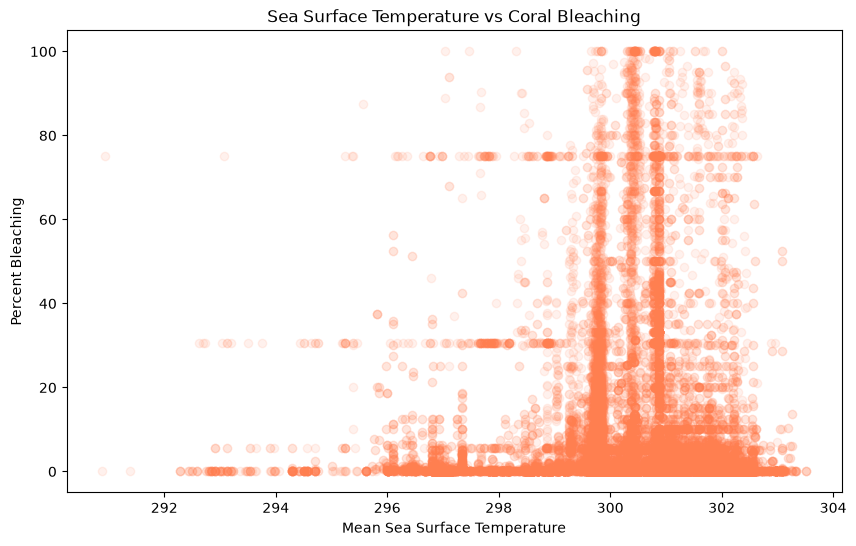

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Temperature_Mean'], df['Percent_Bleaching'], alpha=0.1, color='coral')
plt.xlabel('Mean Sea Surface Temperature')
plt.ylabel('Percent Bleaching')
plt.title('Sea Surface Temperature vs Coral Bleaching')
plt.show()

Degree Heating Weeks vs Bleaching Percentage

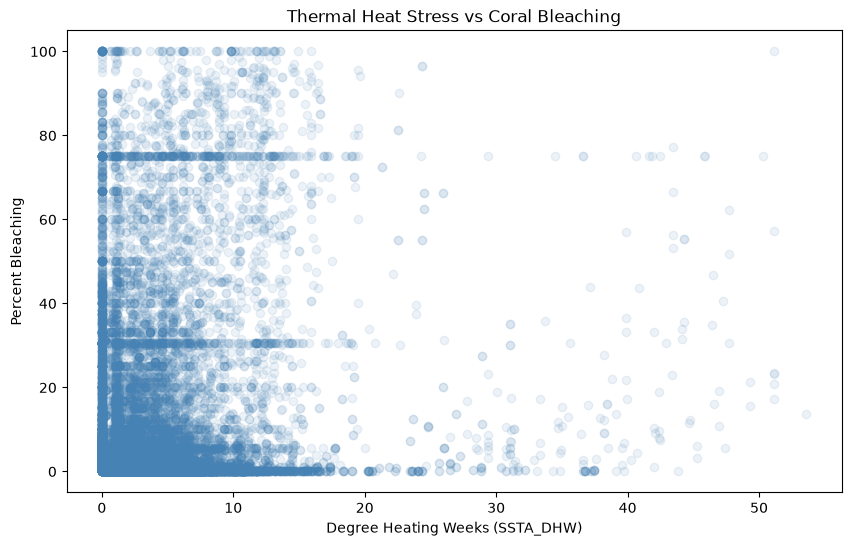

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(df['SSTA_DHW'], df['Percent_Bleaching'], alpha=0.1, color='steelblue')
plt.xlabel('Degree Heating Weeks (SSTA_DHW)')
plt.ylabel('Percent Bleaching')
plt.title('Thermal Heat Stress vs Coral Bleaching')
plt.show()